## Import

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Load dataset:

In [2]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

## Normalize:

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## CNN expects channel dimension. Current shape:
CNN wants:
(60000, 28, 28, 1)
because grayscale = 1 channel.

In [4]:
print(X_train.shape)

(60000, 28, 28)


## Add channel:

In [5]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

## Check:

In [6]:
print(X_train.shape)

(60000, 28, 28, 1)


## Build first CNN

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

C:\Users\SivaGuduri\Desktop\learn-ML\dl-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train model

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9550 - loss: 0.1454
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.9842 - loss: 0.0499
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9890 - loss: 0.0342
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9916 - loss: 0.0258
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9936 - loss: 0.0189


## Test

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9911 - loss: 0.0286
0.991100013256073


## Predict

In [11]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


6
6


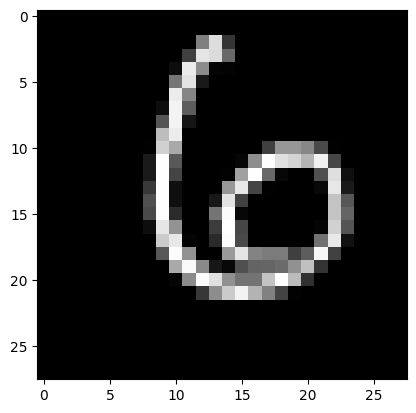

In [14]:
print(np.argmax(predictions[100]))
print(y_test[100])

plt.imshow(X_test[100], cmap="gray")
plt.show()